# Mutagenesis by EMS2

In [1]:
import torch
import esm
import numpy as np
import csv
from tqdm import tqdm
import os

In [2]:
print(torch.__version__)        # Check PyTorch version
print(torch.cuda.is_available())  # Check if CUDA is available
print(torch.version.cuda)        # Check CUDA version

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Version:", torch.version.cuda)
print("cuDNN Version:", torch.backends.cudnn.version())

2.10.0+cu130
True
13.0
PyTorch Version: 2.10.0+cu130
CUDA Available: True
CUDA Version: 13.0
cuDNN Version: 91501


In [3]:
# Load the ESM2 model
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
#model, alphabet = esm.pretrained.esm2_t36_3B_UR50D()
#model, alphabet = esm.pretrained.esm2_t48_15B_UR50D()
batch_converter = alphabet.get_batch_converter()
model = model.eval().to("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# full mutation
out_dir = './output/'
os.makedirs(out_dir, exist_ok=True)

data = [
    ("protein1", "MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR")
]
chain = 'A'
pname = 'Hemo'

# Convert sequences to tokens
batch_labels, batch_strs, batch_tokens = batch_converter(data)
sequence = batch_tokens[0]
sequence_str = batch_strs[0]
sequence_length = sequence.size(0)  # Includes start and end tokens

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
batch_tokens = batch_tokens.to(device)

# Index mappings (Corrected attribute names)
token_to_idx = alphabet.tok_to_idx
idx_to_token = {i: tok for tok, i in token_to_idx.items()}

# List of standard amino acids
standard_aa = [
    "A", "C", "D", "E", "F", "G", "H", "I", "K", "L",
    "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y"
]
aa_indices = [token_to_idx[aa] for aa in standard_aa]

# Prepare lists to store results
probability_results = []
entropy_results = []

# Loop over each position in the sequence (excluding special tokens)
for position_i in tqdm(range(1, sequence_length - 1)):  # Exclude start (<cls>) and end (<eos>) tokens
    # Mask the amino acid at position i
    sequence_masked = sequence.clone()
    sequence_masked[position_i] = alphabet.mask_idx  # Apply mask token

    # Prepare batch
    batch_tokens_masked = sequence_masked.unsqueeze(0)

    # Move to device
    batch_tokens_masked = batch_tokens_masked.to(device)

    # Get the logits for the masked position
    with torch.no_grad():
        outputs = model(batch_tokens_masked, return_contacts=False)
        logits = outputs["logits"]  # Shape: (batch_size, sequence_length, alphabet_size)

    # Extract logits for the masked position
    masked_position_logits = logits[0, position_i, :]  # Shape: (alphabet_size,)

    # Convert logits to probabilities
    probabilities = torch.softmax(masked_position_logits, dim=0)

    # Get probabilities for the 20 standard amino acids
    aa_probs = {}
    total_prob = 0.0
    prob_list = []
    for aa, aa_idx in zip(standard_aa, aa_indices):
        aa_prob = probabilities[aa_idx].item()
        aa_probs[aa] = aa_prob
        prob_list.append(aa_prob)
        total_prob += aa_prob

    # Normalize probabilities (optional)
    for aa in aa_probs:
        aa_probs[aa] /= total_prob
    prob_list = [p / total_prob for p in prob_list]

    # Calculate Shannon entropy
    entropy = -sum(p * np.log2(p) if p > 0 else 0 for p in prob_list)

    # Store the position, original amino acid, and probabilities
    original_aa = sequence_str[position_i - 1]  # Adjust for start token

    # Append to probability results
    prob_result = {
        'Position': position_i,
        'Original_AA': original_aa,
        **aa_probs
    }
    probability_results.append(prob_result)

    # Append to entropy results
    position_identifier = f'/{chain}:{position_i}'
    entropy_results.append({
        'Position_Identifier': position_identifier,
        'Entropy': entropy
    })

# Save amino acid probabilities to a CSV file
prob_output_file = f'{out_dir}{pname}_AA_probabilities.csv'

# Get fieldnames for CSV
fieldnames = ['Position', 'Original_AA'] + standard_aa

with open(prob_output_file, mode='w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    # Write the header
    writer.writeheader()

    # Write data rows
    for result in probability_results:
        writer.writerow(result)

print(f"Amino acid probabilities for all positions have been saved to '{prob_output_file}'.")

# Save Shannon entropy to a text file
entropy_output_file = f'{out_dir}{pname}_shannon_entropy.defattr'

with open(entropy_output_file, 'w') as f:
    f.write("attribute: entropy\n")
    f.write("recipient: residues\n\n")
    for result in entropy_results:
        position_identifier = result['Position_Identifier']
        entropy = result['Entropy']
        f.write(f"\t{position_identifier}\t{entropy}\n")

print(f"Shannon entropy for each position has been saved to '{entropy_output_file}'.")


100%|██████████| 142/142 [00:10<00:00, 13.58it/s]


Amino acid probabilities for all positions have been saved to './output/Hemo_AA_probabilities.csv'.
Shannon entropy for each position has been saved to './output/Hemo_shannon_entropy.defattr'.


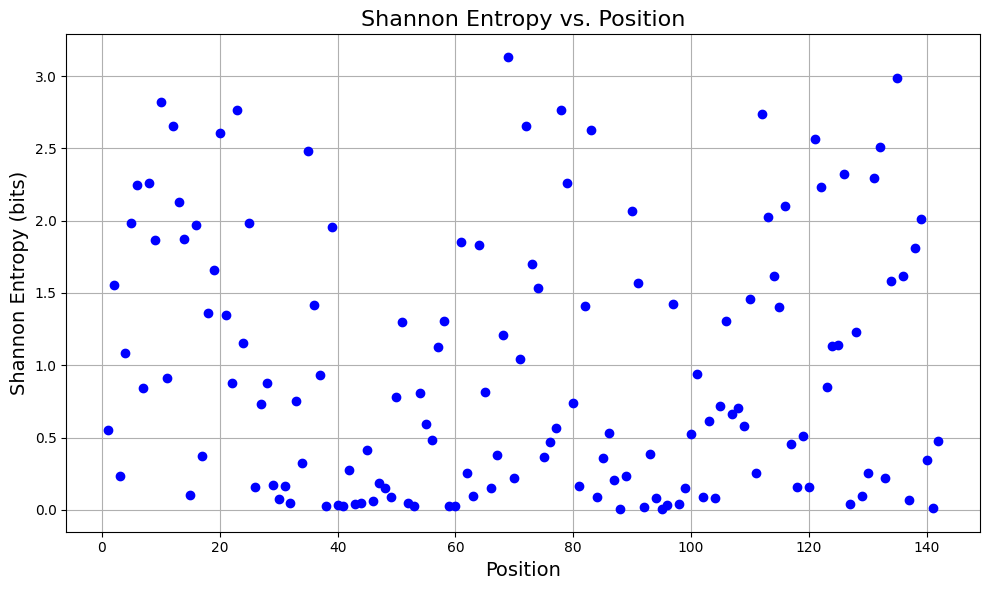

In [5]:
import matplotlib.pyplot as plt
entropy_file = f'{out_dir}{pname}_shannon_entropy.defattr'
positions = []
entropies = []

with open(entropy_file, 'r') as f:
    for i, line in enumerate(f):
        if i < 3:
            continue  # Skip header lines
        line = line.strip()
        if line:
            parts = line.split('\t')
            # Since each line starts with a tab, parts[0] will be empty
            #if len(parts) >= 3:
            position_identifier = parts[0]  # e.g., '/A:1'
            entropy_value = float(parts[1])  # Entropy value
            # Extract the position number from the identifier
            position_str = position_identifier.split(':')[1]
            position = int(position_str)
            positions.append(position)
            entropies.append(entropy_value)

plt.figure(figsize=(10, 6))
plt.plot(positions, entropies, marker='o', linestyle='', color='b')
plt.xlabel('Position', fontsize=14)
plt.ylabel('Shannon Entropy (bits)', fontsize=14)
plt.title('Shannon Entropy vs. Position', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()